# Exploratory Data Analysis

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.lib.connectors import Connectors

print("Imports successful")

Imports successful


In [3]:
s3 = Connectors.connect_s3()
df = Connectors.load_data(s3)

print(f"✓ Shape: {df.shape}")
print(f"✓ Fraud rate: {df['Class'].mean()*100:.3f}%")

Access key loaded: AKIA6...OYKM
Secret key loaded: ********************
Region: us-east-1
Bucket: card-fraud-detection-01

Verifying AWS connection...
Connected to AWS
Account ID: 977237814864
User: arn:aws:iam::977237814864:root
Local cache found — loading from disk...
Loaded in 0.6s
✓ Shape: (284807, 31)
✓ Fraud rate: 0.173%


## Class Distribution

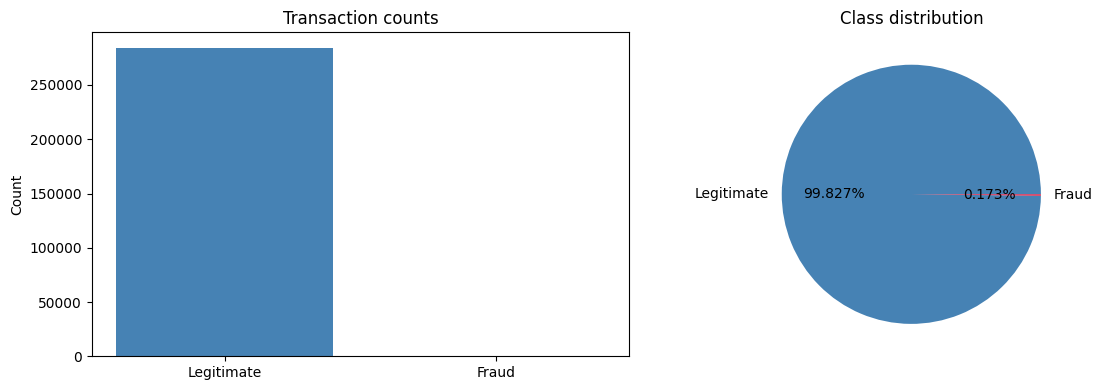

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], df['Class'].value_counts(), color=['steelblue', 'crimson'])
axes[0].set_title('Transaction counts')
axes[0].set_ylabel('Count')

fraud_pct = df['Class'].mean() * 100
axes[1].pie([100 - fraud_pct, fraud_pct], labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'], autopct='%1.3f%%')
axes[1].set_title('Class distribution')

plt.tight_layout()
plt.show()

## Transaction Amounts

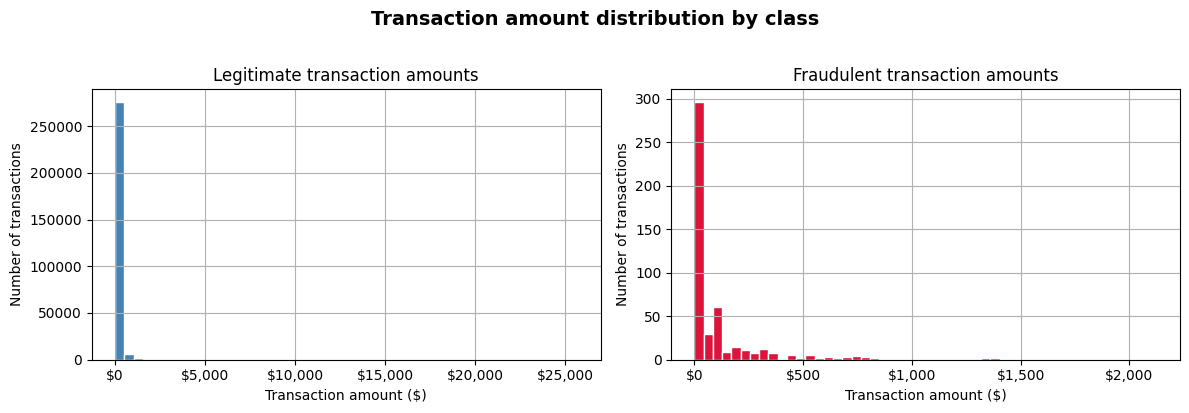

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Legitimate transaction amounts')
axes[0].set_xlabel('Transaction amount ($)')
axes[0].set_ylabel('Number of transactions')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Fraudulent transaction amounts')
axes[1].set_xlabel('Transaction amount ($)')
axes[1].set_ylabel('Number of transactions')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.suptitle('Transaction amount distribution by class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Feature Correlation

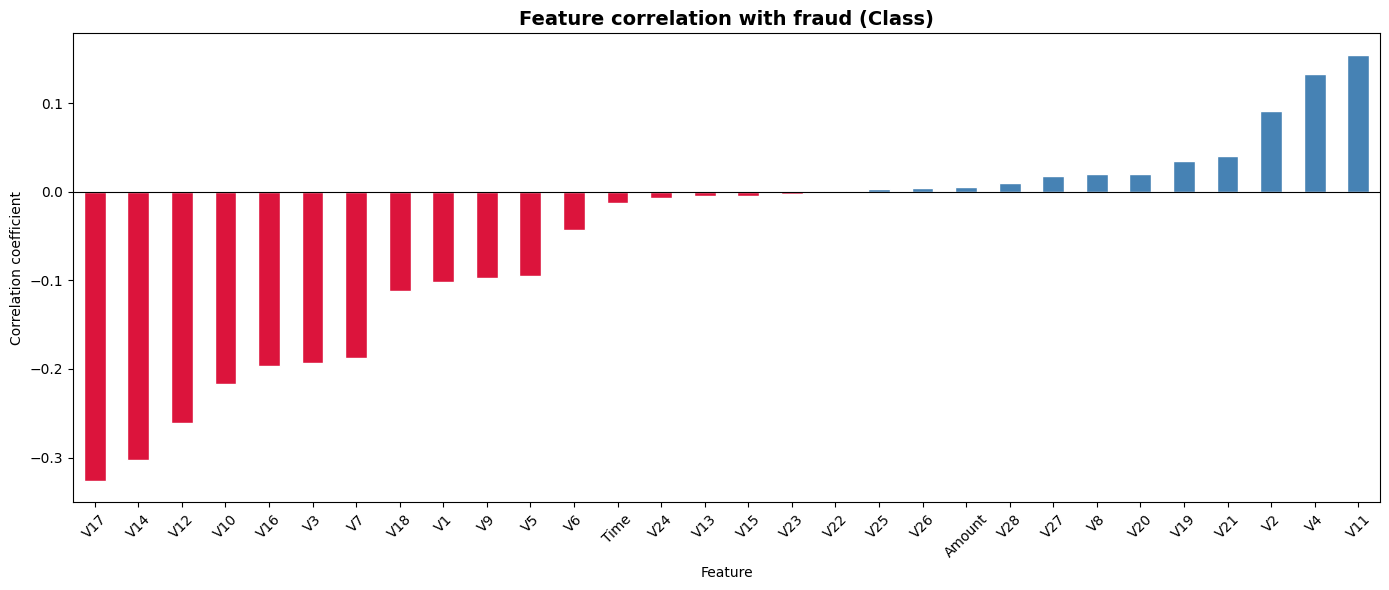

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

correlations = df.corr()['Class'].drop('Class').sort_values()
colors = ['crimson' if x < 0 else 'steelblue' for x in correlations]
correlations.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Feature correlation with fraud (Class)', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Correlation coefficient')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Specific Class Distributions

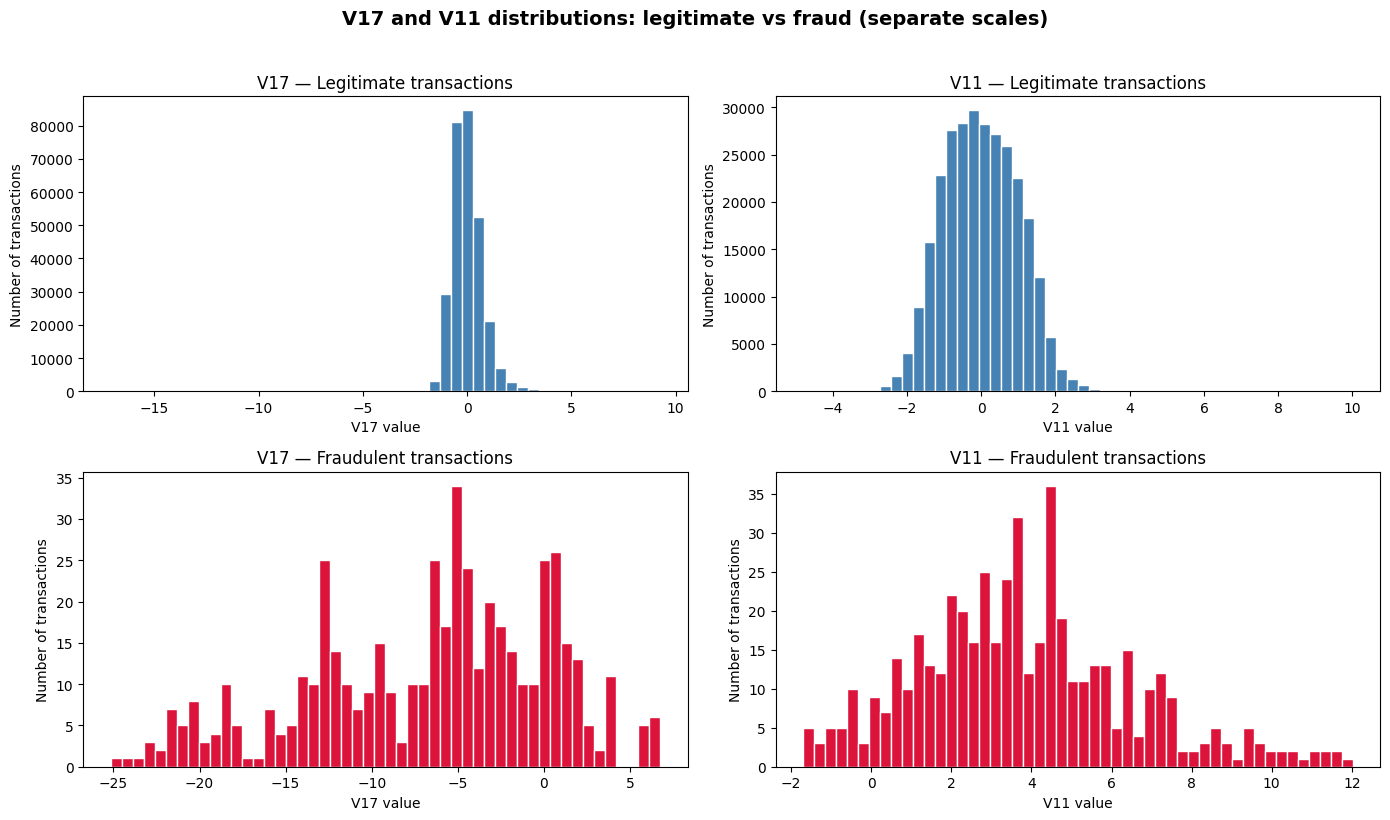

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, feature in enumerate(['V17', 'V11']):
    axes[0][idx].hist(df[df['Class'] == 0][feature], bins=50,
                      color='steelblue', edgecolor='white')
    axes[0][idx].set_title(f'{feature} — Legitimate transactions')
    axes[0][idx].set_xlabel(f'{feature} value')
    axes[0][idx].set_ylabel('Number of transactions')

    axes[1][idx].hist(df[df['Class'] == 1][feature], bins=50,
                      color='crimson', edgecolor='white')
    axes[1][idx].set_title(f'{feature} — Fraudulent transactions')
    axes[1][idx].set_xlabel(f'{feature} value')
    axes[1][idx].set_ylabel('Number of transactions')

plt.suptitle('V17 and V11 distributions: legitimate vs fraud (separate scales)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()